# 11 · NMF Benchmark — 4 Variants × 4 Architectures

Definitive comparison of the four NMF backends used in BFT:
**sklearn · r1d · r1d_sparse · r1d_sparse2**

| Model | Architecture | Checkpoint |
|-------|-------------|------------|
| M1    | MNIST even/odd MLP 8-4 (digits 0134) | `experiments/mnist_even_odd_mlp_8_4_0134/` |
| M2    | MNIST digit MLP 40-20 (10 classes)   | `experiments/mnist_digit_mlp_40_20/`        |
| M3    | CIFAR-10 CNN (SmallCNN inline)        | `data/cache/nb04/weights/weights.pt`        |
| M4    | Tiny ViT (MNIST even/odd)             | `experiments/mnist_even_odd_vit_tiny/`      |

**Each model section contains:**
- **§B1** Per-layer reconstruction error curves (k=1..K_MAX, all 4 NMFs)
- **§B2** Per-layer sparsity profiles (W and H factors)
- **§B3** BFT wall-clock timing
- **§B4** Auto-selected K* per NMF
- **§B5** 4×4 Hungarian cosine similarity heatmap
- **§C**  Qualitative: top-2 factor panels + scaffold graphs for each NMF
- **§D**  Per-class specificity ablation (M1–M3; ViT skipped — no named submodule access)

**§5** concludes with an aggregate summary table across all models.

> Requires nb05 to have been re-run (to save the transformer checkpoint).

In [1]:
import sys, os, time, json, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import linear_sum_assignment

from src import (
    load_experiment, get_loaders_from_config,
    collect_layer_inputs, collect_layer_data,
    get_mnist_loaders, get_cifar10_loaders,
    full_nmf_pipeline, auto_nmf_pipeline, bft,
    compute_joint_arbors_normalized, compute_conv_joint_arbors, compute_attn_joint_arbors,
    label_transform_even_odd,
    build_scaffold_edges, scaffold_loading_from_edges, scaffold_layer_sizes_from_edges,
    plot_scaffold_graph,
    extract_importance_scores, magnitude_scores, run_ablation_sweep,
    ablate_model, per_class_accuracy,
)
from src.r1d import rec_err_curve
from src.training import correct

matplotlib.rcParams.update({'figure.dpi': 90})
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cpu


In [2]:
NMF_VARIANTS   = ['sklearn', 'r1d', 'r1d_sparse', 'r1d_sparse2']
NMF_COLORS     = {'sklearn': '#1f77b4', 'r1d': '#ff7f0e',
                  'r1d_sparse': '#2ca02c', 'r1d_sparse2': '#d62728'}

K_MAX_BENCH    = 10   # rank upper-bound for single-layer benchmarks
K_MAX_BFT      = 8    # rank upper-bound passed to bft()
N_BRANCHES_MLP = 2    # BFT branches per layer (MLP models)
ABLATION_FRACS = [0.05, 0.10, 0.20, 0.30, 0.50]
N_TOP_IMGS     = 4    # top-N active images to show per factor

SUMMARY_ROWS = []  # populated at the end of each model section

In [3]:
# ─── Helper: single-layer NMF benchmark ───────────────────────────────────────

def run_layer_benchmark(J, k_max=K_MAX_BENCH):
    """Run all 4 NMF variants on joint-arbor matrix J.

    Returns dict keyed by variant name with keys:
      time, recon_curve, k_star, img_f, neu_f, lams, sparsity_img, sparsity_neu
    """
    out = {}
    J_pos = np.clip(J, 0, None)
    for v in NMF_VARIANTS:
        t0 = time.perf_counter()
        img_f, neu_f, lams = full_nmf_pipeline(J_pos, k_max, factorizer=v)
        elapsed = time.perf_counter() - t0
        errs = rec_err_curve(J_pos, img_f, neu_f)
        _, _, _, k_star = auto_nmf_pipeline(J_pos, k_max=k_max, factorizer=v)
        out[v] = dict(
            time=elapsed, recon_curve=errs, k_star=k_star,
            img_f=img_f, neu_f=neu_f, lams=lams,
            sparsity_img=float(np.mean(np.abs(img_f) < 1e-3)),
            sparsity_neu=float(np.mean(np.abs(neu_f) < 1e-3)),
        )
    return out


def hungarian_sim_matrix(bench_results):
    """4×4 pairwise Hungarian-matched cosine similarity on neural factors (neu_f)."""
    variants = list(bench_results.keys())
    n = len(variants)
    mat = np.eye(n)
    for i, va in enumerate(variants):
        for j, vb in enumerate(variants):
            if i == j: continue
            Ha = bench_results[va]['neu_f']
            Hb = bench_results[vb]['neu_f']
            k  = min(Ha.shape[1], Hb.shape[1])
            Ha_k = Ha[:, :k] / (np.linalg.norm(Ha[:, :k], axis=0, keepdims=True) + 1e-12)
            Hb_k = Hb[:, :k] / (np.linalg.norm(Hb[:, :k], axis=0, keepdims=True) + 1e-12)
            C = Ha_k.T @ Hb_k  # (k, k)
            ri, ci = linear_sum_assignment(-C)
            mat[i, j] = float(C[ri, ci].mean())
    return mat, variants


# ─── Helper: per-layer plot (recon + sparsity) ─────────────────────────────────

def plot_layer_recon_sparsity(layer_bench_list, layer_names, title_prefix=''):
    """For each layer, plot recon error curves and sparsity bars."""
    n_layers = len(layer_bench_list)
    fig, axes = plt.subplots(2, n_layers, figsize=(4 * n_layers, 7))
    if n_layers == 1:
        axes = axes[:, np.newaxis]

    for li, (bench, lname) in enumerate(zip(layer_bench_list, layer_names)):
        ax_r = axes[0, li]
        ax_s = axes[1, li]

        # Recon error curves
        for v in NMF_VARIANTS:
            errs = bench[v]['recon_curve']
            ks   = np.arange(1, len(errs) + 1)
            ax_r.plot(ks, errs, color=NMF_COLORS[v], label=v, lw=1.8)
            k_star = bench[v]['k_star']
            ax_r.axvline(k_star, color=NMF_COLORS[v], ls='--', lw=0.8, alpha=0.6)
        ax_r.set(title=f'{lname}\nRecon error vs k', xlabel='k',
                 ylabel='||A-X_k||_F / ||A||_F')
        ax_r.legend(fontsize=7)
        ax_r.set_ylim(bottom=0)

        # Sparsity bars (W and H, side by side)
        x = np.arange(len(NMF_VARIANTS))
        w_sparse = [bench[v]['sparsity_img'] for v in NMF_VARIANTS]
        h_sparse = [bench[v]['sparsity_neu'] for v in NMF_VARIANTS]
        bars1 = ax_s.bar(x - 0.2, w_sparse, 0.35, label='img (W)', alpha=0.8)
        bars2 = ax_s.bar(x + 0.2, h_sparse, 0.35, label='neu (H)', alpha=0.8)
        for b, c in zip(bars1, [NMF_COLORS[v] for v in NMF_VARIANTS]):
            b.set_color(c)
        for b, c in zip(bars2, [NMF_COLORS[v] for v in NMF_VARIANTS]):
            b.set_color(c); b.set_alpha(0.4)
        ax_s.set(title=f'{lname}\nSparsity (|x|<1e-3)', ylabel='fraction near-zero')
        ax_s.set_xticks(x); ax_s.set_xticklabels(NMF_VARIANTS, rotation=20, fontsize=7)
        ax_s.legend(fontsize=7)
        ax_s.set_ylim(0, 1)

    fig.suptitle(f'{title_prefix} — Per-layer reconstruction & sparsity', fontsize=12)
    plt.tight_layout()
    plt.show()


def print_quant_table(layer_bench_list, layer_names, bft_times, title_prefix=''):
    """Print timing, K*, Hungarian similarity as a formatted table."""
    import pandas as pd
    rows = []
    for li, (bench, lname) in enumerate(zip(layer_bench_list, layer_names)):
        hung_mat, variants = hungarian_sim_matrix(bench)
        for vi, v in enumerate(NMF_VARIANTS):
            # Average Hungarian similarity vs all other variants
            other_sims = [hung_mat[vi, j] for j in range(len(variants)) if j != vi]
            rows.append({
                'layer': lname, 'variant': v,
                'layer_time_s': round(bench[v]['time'], 3),
                'k_star': bench[v]['k_star'],
                'recon@k_star': round(float(bench[v]['recon_curve'][bench[v]['k_star'] - 1]), 4),
                'hung_sim_avg': round(float(np.mean(other_sims)), 4),
                'sparsity_neu': round(bench[v]['sparsity_neu'], 4),
            })
    df = pd.DataFrame(rows)
    print(f'\n{title_prefix} — Quantitative summary')
    print(df.to_string(index=False))

    # BFT timing
    if bft_times:
        print('\nBFT wall-clock times:')
        for v, t in bft_times.items():
            print(f'  {v:<15} {t:.1f}s')

    return df


def plot_hung_heatmap(bench, title=''):
    """4×4 pairwise Hungarian similarity heatmap for one layer's benchmark."""
    mat, variants = hungarian_sim_matrix(bench)
    fig, ax = plt.subplots(figsize=(4, 3.5))
    im = ax.imshow(mat, vmin=0, vmax=1, cmap='RdYlGn')
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(variants, rotation=30, fontsize=8)
    ax.set_yticklabels(variants, fontsize=8)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(f'{title}\nHungarian cosine similarity', fontsize=10)
    plt.tight_layout()
    plt.show()


# ─── Helper: qualitative factor visualization ──────────────────────────────────

def viz_top_factors(tree, all_images, all_targets, class_names,
                    n_factors=2, n_imgs=4, variant_name='sklearn', is_mnist=True):
    """Show top n_factors factor panels from BFT root node."""
    node  = tree  # root = last/output layer
    img_f = node['img_factors']
    neu_f = node['neural_factors']
    lams  = node['lambdas']
    W     = node['W']
    n_out, n_in = W.shape
    n_show = min(n_factors, len(lams))

    fig, axes = plt.subplots(n_show, 2 + n_imgs, figsize=(3 * (2 + n_imgs), 2.8 * n_show))
    if n_show == 1:
        axes = axes[np.newaxis, :]

    for fi in range(n_show):
        coefs    = img_f[:, fi]
        per_neu  = neu_f[:, fi].reshape(n_out, n_in)
        w_norm   = coefs / (coefs.sum() + 1e-12)

        # Weighted average image
        ax_img = axes[fi, 0]
        if is_mnist:
            w_avg = (w_norm[:, None, None] * all_images[:, 0]).sum(0)
            ax_img.imshow(w_avg, cmap='gray')
        else:
            w_avg = (w_norm[:, None, None, None] * all_images).sum(0)
            w_avg_disp = np.clip(w_avg.transpose(1, 2, 0), 0, 1)
            ax_img.imshow(w_avg_disp)
        ax_img.set(title=f'f{fi}  λ={lams[fi]:.2f}\nwtd avg', xticks=[], yticks=[])

        # Neural factor heatmap
        ax_nf  = axes[fi, 1]
        vmax   = np.abs(per_neu).max() or 1.0
        ax_nf.imshow(per_neu, aspect='auto', cmap='PuRd', vmin=0, vmax=vmax)
        ax_nf.set(title=f'neural factor\n({n_out}×{n_in})',
                  xlabel='input', ylabel='output')

        # Top-N active images
        top_idx = np.argsort(coefs)[::-1][:n_imgs]
        for ci, s_idx in enumerate(top_idx):
            ax = axes[fi, 2 + ci]
            if is_mnist:
                ax.imshow(all_images[s_idx, 0], cmap='gray')
            else:
                ax.imshow(np.clip(all_images[s_idx].transpose(1, 2, 0), 0, 1))
            cl = int(all_targets[s_idx])
            ax.set(title=class_names.get(cl, str(cl)), xticks=[], yticks=[])

    fig.suptitle(f'{variant_name} — root layer top-{n_show} factors', fontsize=11)
    plt.tight_layout()
    plt.show()


def viz_scaffold(tree, layer_sizes, variant_name='sklearn'):
    """Draw scaffold graph for the first path in the BFT tree."""
    def _all_paths(root):
        if not root['children']: return [[root]]
        return [[root] + p for c in root['children'] for p in _all_paths(c)]

    paths = _all_paths(tree)
    path  = paths[0]
    layer_results = list(reversed(path))  # input-side first
    edge_matrices, neg_edge_matrices = build_scaffold_edges(
        layer_results[1:], fi='path', fi_seed=layer_results[0])
    loading = scaffold_loading_from_edges(edge_matrices)
    actual_sizes = scaffold_layer_sizes_from_edges(edge_matrices)
    fig = plot_scaffold_graph(loading, edge_matrices, actual_sizes,
                              neg_edge_matrices=neg_edge_matrices)
    fig.suptitle(f'{variant_name} — scaffold (path 0)', fontsize=10)
    plt.tight_layout()
    plt.show()


# ─── Helper: ablation ──────────────────────────────────────────────────────────

def run_ablation_comparison(model, bft_trees, test_loader, label_transform,
                             n_branches=2):
    """Compare ablation AUC for BFT importance (all 4 NMFs), magnitude, and random."""
    import pandas as pd

    scores_dict = {}
    for v, tree in bft_trees.items():
        def _all_paths(root):
            if not root['children']: return [[root]]
            return [[root] + p for c in root['children'] for p in _all_paths(c)]
        paths = _all_paths(tree)
        scores = extract_importance_scores(list(reversed(paths[0])))
        scores_dict[v] = scores

    scores_dict['magnitude'] = magnitude_scores(model)

    results_all = {}
    for name, scores in scores_dict.items():
        results_all[name] = run_ablation_sweep(
            model, scores, ABLATION_FRACS, test_loader, label_transform, device)

    # Random baseline
    dummy_keys = list(scores_dict['magnitude'].keys())
    random_scores = {k: 0.0 for k in dummy_keys}
    results_all['random'] = run_ablation_sweep(
        model, random_scores, ABLATION_FRACS, test_loader, label_transform, device,
        method='random')

    # Plot
    fig, ax = plt.subplots(figsize=(7, 4))
    classes = sorted(results_all['sklearn'][ABLATION_FRACS[0]].keys())

    # Mean accuracy across classes
    auc_rows = []
    all_colors = list(NMF_COLORS.values()) + ['#9467bd', '#8c564b']
    for ni, (name, results) in enumerate(results_all.items()):
        accs = [np.mean([results[f][c] for c in classes]) for f in ABLATION_FRACS]
        ax.plot(ABLATION_FRACS, accs, 'o-',
                color=all_colors[ni % len(all_colors)], label=name, lw=2)
        auc = float(np.trapezoid(accs, ABLATION_FRACS))
        auc_rows.append({'method': name, 'mean_ablation_auc': round(auc, 4)})

    ax.set(xlabel='Fraction ablated', ylabel='Mean accuracy',
           title='Ablation: mean accuracy vs fraction of top-weighted removed')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    df_auc = pd.DataFrame(auc_rows).sort_values('mean_ablation_auc')
    print('\nAblation AUC (lower = more causal importance identified):')
    print(df_auc.to_string(index=False))
    return df_auc


In [4]:
# ─── Per-class specificity ablation ────────────────────────────────────────────

SPEC_FRACS = [0.10, 0.20, 0.50]  # fractions used for per-class ablation (fewer than ABLATION_FRACS for speed)

def run_per_class_ablation(model, layer_inputs, targets, test_loader,
                            label_transform, fast=False):
    """
    Per-class specificity ablation following nb03 §2-3 methodology.

    For each NMF variant and each class d:
      1. Filter layer_inputs to class-d samples; optionally subsample (fast=True).
      2. Run BFT (n_branches=1) on class-d samples → single traced path.
      3. Full-path: ablate union of all-layer class-d weights; measure target vs bystander drop.
      4. Per-layer: for each node along path, ablate that layer only.

    Returns dict:
      variant → {ratio_full, full_targets, full_bystanders, layer_ratios, layer_names}

    Set fast=True to skip r1d and r1d_sparse2 (identical to r1d_sparse) and
    subsample to 300 class-d samples for speed on larger models.
    """
    import pandas as pd

    classes = sorted(int(c) for c in np.unique(targets).tolist())
    n_c = len(classes)
    variants = ['sklearn', 'r1d_sparse'] if fast else NMF_VARIANTS

    # Baseline (unablated) per-class accuracy
    baseline = per_class_accuracy(model, test_loader, label_transform, device)

    def _first_path(tree):
        """Follow top child from root (output layer) toward input. Output-layer first."""
        path, node = [], tree
        while node:
            path.append(node)
            node = node['children'][0] if node['children'] else None
        return path

    def _eval_drop(model_orig, keys):
        """Ablate keys in a copy, return {class: accuracy_drop}."""
        m_abl = ablate_model(model_orig, keys)
        accs  = per_class_accuracy(m_abl, test_loader, label_transform, device)
        return {c: baseline.get(c, 1.0) - accs.get(c, 0.0) for c in classes}

    all_results = {}
    for v in variants:
        print(f'  [{v}]', end=' ', flush=True)
        full_targets, full_bystanders = [], []
        layer_t = {}; layer_b = {}  # lname → list of per-class means

        for d in classes:
            mask_d = (targets == d)
            li_d = [li[mask_d] for li in layer_inputs]
            if fast and mask_d.sum() > 300:
                idx = np.random.choice(mask_d.sum(), 300, replace=False)
                li_d = [a[idx] for a in li_d]

            tree_d = bft(model, li_d, k_max=K_MAX_BFT, n_branches=1, factorizer=v, verbose=0)
            path = _first_path(tree_d)

            # (a) Full-path ablation
            full_scores = extract_importance_scores(path)
            ft_list, fb_list = [], []
            for frac in SPEC_FRACS:
                n_k = max(1, int(frac * len(full_scores)))
                top_keys = sorted(full_scores, key=full_scores.get, reverse=True)[:n_k]
                drops = _eval_drop(model, top_keys)
                ft_list.append(drops[d])
                fb_list.append(np.mean([drops[c] for c in classes if c != d]))
            full_targets.append(np.mean(ft_list))
            full_bystanders.append(np.mean(fb_list))

            # (b) Per-layer ablation along path
            for node in path:
                lname = f'L{node["layer_idx"]}'
                node_scores = extract_importance_scores([node])
                if not node_scores:
                    continue
                lt_list, lb_list = [], []
                for frac in SPEC_FRACS:
                    n_k = max(1, int(frac * len(node_scores)))
                    top_keys = sorted(node_scores, key=node_scores.get, reverse=True)[:n_k]
                    drops = _eval_drop(model, top_keys)
                    lt_list.append(drops[d])
                    lb_list.append(np.mean([drops[c] for c in classes if c != d]))
                layer_t.setdefault(lname, []).append(np.mean(lt_list))
                layer_b.setdefault(lname, []).append(np.mean(lb_list))

        ratio_full = float(np.mean(full_targets) / (np.mean(full_bystanders) + 1e-9))
        layer_ratios = {
            ln: float(np.mean(layer_t[ln]) / (np.mean(layer_b[ln]) + 1e-9))
            for ln in layer_t
        }
        layer_names = sorted(layer_t.keys())
        print(f'ratio={ratio_full:.3f}  per-layer={layer_ratios}')
        all_results[v] = dict(
            ratio_full=ratio_full,
            full_targets=full_targets,
            full_bystanders=full_bystanders,
            layer_ratios=layer_ratios,
            layer_names=layer_names,
        )

    return all_results


def plot_spec_results(spec_results, title_prefix='', class_names=None):
    """Visualise per-class ablation results: ratio bar, per-layer profile."""
    import pandas as pd
    variants = list(spec_results.keys())

    # ── (1) full-path specificity ratio bar chart ──
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    ax = axes[0]
    ratios = [spec_results[v]['ratio_full'] for v in variants]
    bars = ax.bar(range(len(variants)), ratios,
                  color=[NMF_COLORS.get(v, 'gray') for v in variants])
    ax.axhline(1.0, color='k', ls='--', lw=1, label='no specificity (=1)')
    ax.set_xticks(range(len(variants))); ax.set_xticklabels(variants, rotation=20, fontsize=8)
    ax.set(title=f'{title_prefix}\nFull-path specificity ratio (higher = better)',
           ylabel='target drop / bystander drop')
    ax.legend(fontsize=7)

    # ── (2) per-layer specificity profile ──
    ax2 = axes[1]
    all_layers = sorted({ln for v in variants for ln in spec_results[v]['layer_ratios']})
    x = np.arange(len(all_layers))
    w = 0.8 / len(variants)
    for vi, v in enumerate(variants):
        layer_r = [spec_results[v]['layer_ratios'].get(ln, float('nan')) for ln in all_layers]
        ax2.bar(x + vi * w - 0.4 + w/2, layer_r, w,
                color=NMF_COLORS.get(v, 'gray'), label=v, alpha=0.85)
    ax2.axhline(1.0, color='k', ls='--', lw=1)
    ax2.set_xticks(x); ax2.set_xticklabels(all_layers, fontsize=8)
    ax2.set(title='Per-layer specificity ratio\n(L0=input side, higher layer = closer to output)',
            ylabel='target drop / bystander drop')
    ax2.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

    # ── (3) print summary table ──
    rows = [{'variant': v, 'ratio_full': round(spec_results[v]['ratio_full'], 4),
             **{ln: round(spec_results[v]['layer_ratios'].get(ln, float('nan')), 4)
                for ln in all_layers}}
            for v in variants]
    df = pd.DataFrame(rows)
    print(f'\n{title_prefix} specificity summary:')
    print(df.to_string(index=False))
    return df


---
## §1  MNIST Even/Odd MLP — 8-4 hidden units, digits 0,1,3,4

In [5]:
# Load model and config
M1_DIR = '../experiments/mnist_even_odd_mlp_8_4_0134'
m1_model, m1_cfg = load_experiment(M1_DIR, device)
print(m1_cfg)

# Data: only digits 0,1,3,4 (matching training)
digit_filter = m1_cfg.get('dataset_kwargs', {}).get('digit_filter', [0, 1, 3, 4])
_, m1_test_ds = get_mnist_loaders(batch_size=256, digit_filter=digit_filter, root='../data/')
m1_test_loader = torch.utils.data.DataLoader(m1_test_ds.dataset, batch_size=256, shuffle=False)

m1_data = collect_layer_inputs(
    m1_model, m1_test_ds.dataset,
    label_transform=label_transform_even_odd, device=device)

m1_images        = m1_data['images']         # (N, 1, 28, 28)
m1_targets       = m1_data['targets']        # (N,) 0=even 1=odd
m1_digits        = m1_data['digits']         # (N,) original
m1_layer_inputs  = m1_data['layer_inputs']   # list per linear layer
M1_CLASS_NAMES   = {0: 'even', 1: 'odd'}
M1_LAYER_SIZES   = list(m1_cfg['arch_kwargs']['hidden_dims']) + [m1_cfg['arch_kwargs']['output_dim']]

print(f'Samples: {len(m1_targets)}  Layer sizes: {M1_LAYER_SIZES}')
for li, li_arr in enumerate(m1_layer_inputs):
    print(f'  layer_inputs[{li}]: {li_arr.shape}')

{'arch': 'SimpleMLP', 'arch_kwargs': {'input_dim': 784, 'hidden_dims': [8, 4], 'output_dim': 2}, 'dataset': 'MNIST', 'dataset_kwargs': {'batch_size': 32, 'root': '../data/', 'digit_filter': [0, 1, 3, 4]}, 'label_transform': 'even_odd', 'analysis_layer_indices': [2, 4, 6], 'n_per_class': 1000, 'input_side': 28, 'description': 'SimpleMLP 784→10→5→2 on MNIST even/odd, digits 0,1,3,4 only'}
Samples: 4078  Layer sizes: [8, 4, 2]
  layer_inputs[0]: (4078, 784)
  layer_inputs[1]: (4078, 8)
  layer_inputs[2]: (4078, 4)


In [6]:
# Pre-compute per-layer joint arbors (uniform stimulus weights)
m1_arbors = []
m1_layer_names = []
lin_idxs = m1_model.linear_layer_indices()
for li_pos, lin_idx in enumerate(lin_idxs):
    W   = m1_model.layers[lin_idx].weight.detach().cpu().numpy()
    act = m1_layer_inputs[li_pos]
    J   = compute_joint_arbors_normalized(W, act)
    m1_arbors.append(np.clip(J, 0, None))
    m1_layer_names.append(f'L{li_pos+1} ({W.shape[0]}×{W.shape[1]})')
    print(f'  Layer {li_pos+1}: W={W.shape}  J={J.shape}')

  Layer 1: W=(8, 784)  J=(4078, 6272)
  Layer 2: W=(4, 8)  J=(4078, 32)
  Layer 3: W=(2, 4)  J=(4078, 8)


Running per-layer NMF benchmarks for M1...
  Layer 1/3 done
  Layer 2/3 done
  Layer 3/3 done


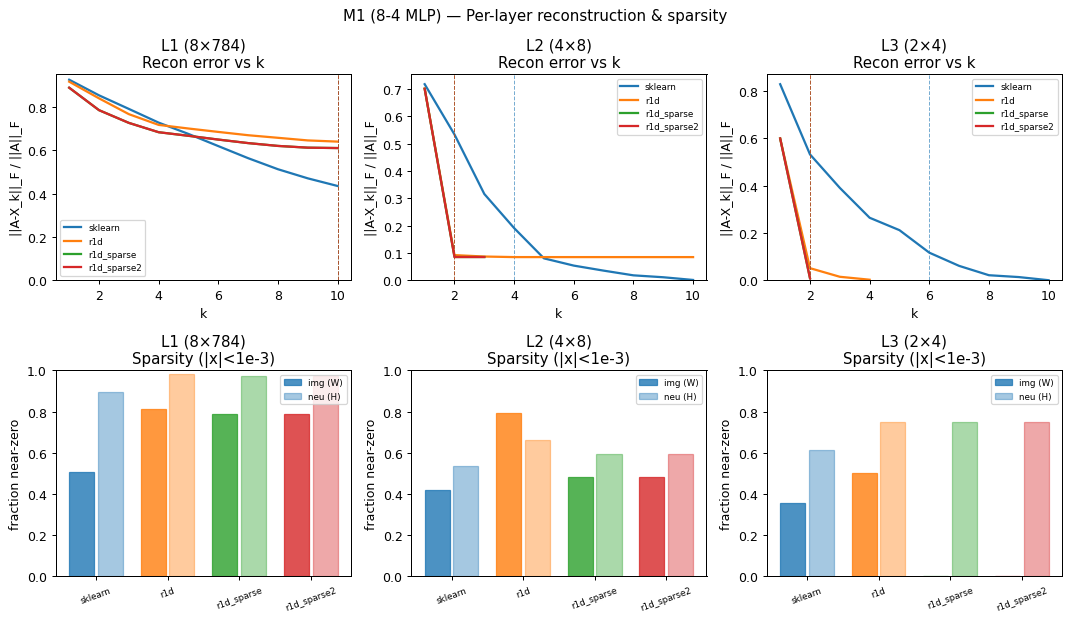

In [7]:
# §B1-B2: Per-layer benchmark (recon + sparsity)
print('Running per-layer NMF benchmarks for M1...')
m1_layer_bench = []
for li, J in enumerate(m1_arbors):
    print(f'  Layer {li+1}/{len(m1_arbors)}', end=' ')
    bench = run_layer_benchmark(J, k_max=K_MAX_BENCH)
    m1_layer_bench.append(bench)
    print('done')

plot_layer_recon_sparsity(m1_layer_bench, m1_layer_names, title_prefix='M1 (8-4 MLP)')

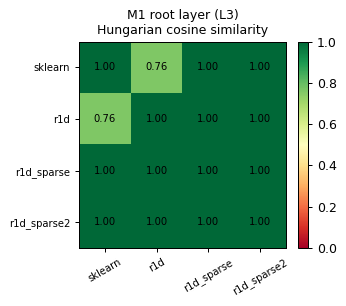

In [8]:
# §B5: Hungarian similarity for root layer
plot_hung_heatmap(m1_layer_bench[-1], title='M1 root layer (L3)')

In [9]:
# §B3: BFT timing + §C: Qualitative viz
print('Running BFT for all 4 NMF variants on M1...')
m1_bft_trees = {}
m1_bft_times = {}
for v in NMF_VARIANTS:
    print(f'  {v}...', end=' ', flush=True)
    t0 = time.perf_counter()
    m1_bft_trees[v] = bft(
        m1_model, m1_layer_inputs,
        k_max=K_MAX_BFT, n_branches=N_BRANCHES_MLP,
        factorizer=v, verbose=0)
    m1_bft_times[v] = time.perf_counter() - t0
    print(f'{m1_bft_times[v]:.1f}s')

# Merge BFT timing into quant table
m1_df = print_quant_table(m1_layer_bench, m1_layer_names, m1_bft_times, 'M1')

Running BFT for all 4 NMF variants on M1...
  sklearn... 17.8s
  r1d... 7.1s
  r1d_sparse... 3.4s
  r1d_sparse2... 3.7s

M1 — Quantitative summary
     layer     variant  layer_time_s  k_star  recon@k_star  hung_sim_avg  sparsity_neu
L1 (8×784)     sklearn         1.314      10        0.4357        0.6463        0.8932
L1 (8×784)         r1d         1.443      10        0.6407        0.6738        0.9841
L1 (8×784)  r1d_sparse         0.682      10        0.6110        0.7697        0.9720
L1 (8×784) r1d_sparse2         1.034      10        0.6109        0.7705        0.9720
  L2 (4×8)     sklearn         0.037       4        0.1912        0.8835        0.5344
  L2 (4×8)         r1d         0.022       2        0.0923        0.8447        0.6625
  L2 (4×8)  r1d_sparse         0.008       2        0.0854        0.9419        0.5938
  L2 (4×8) r1d_sparse2         0.005       2        0.0854        0.9419        0.5938
  L3 (2×4)     sklearn         0.008       6        0.1168        0.91

=== sklearn ===


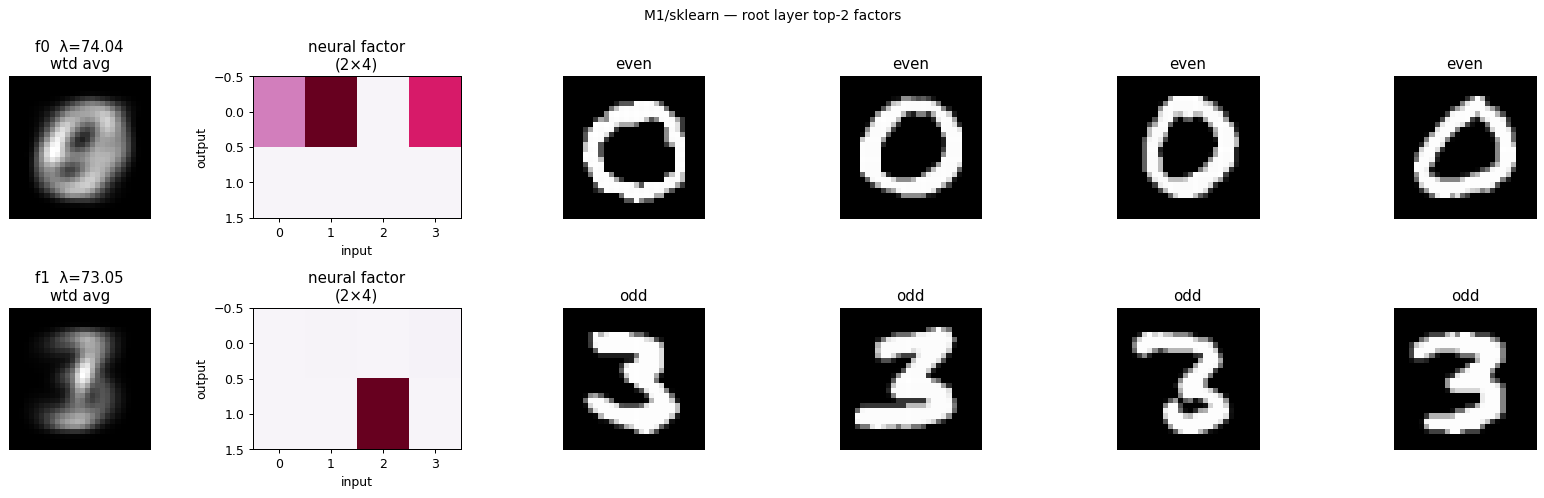

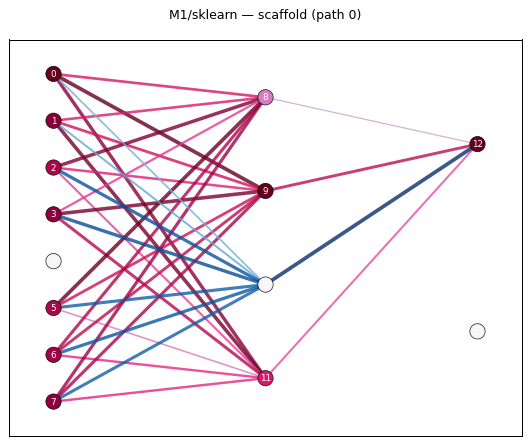

=== r1d ===


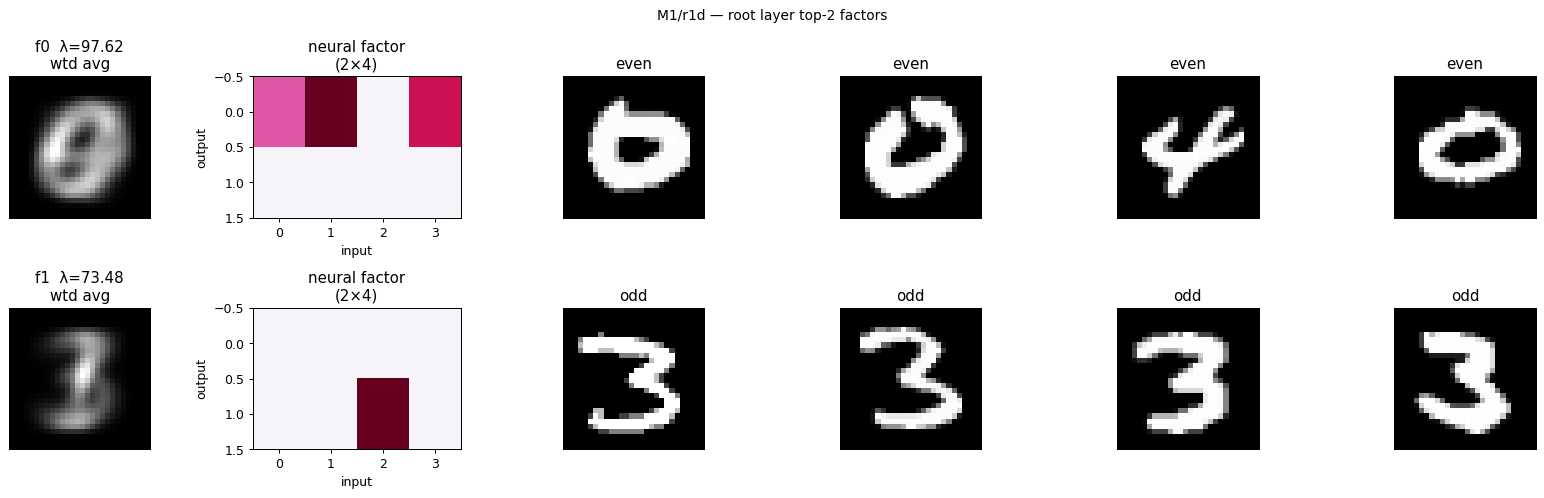

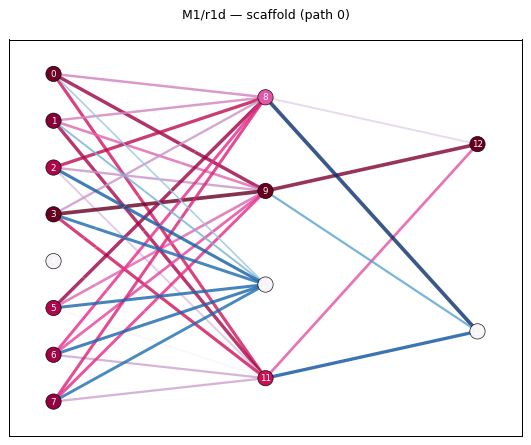

=== r1d_sparse ===


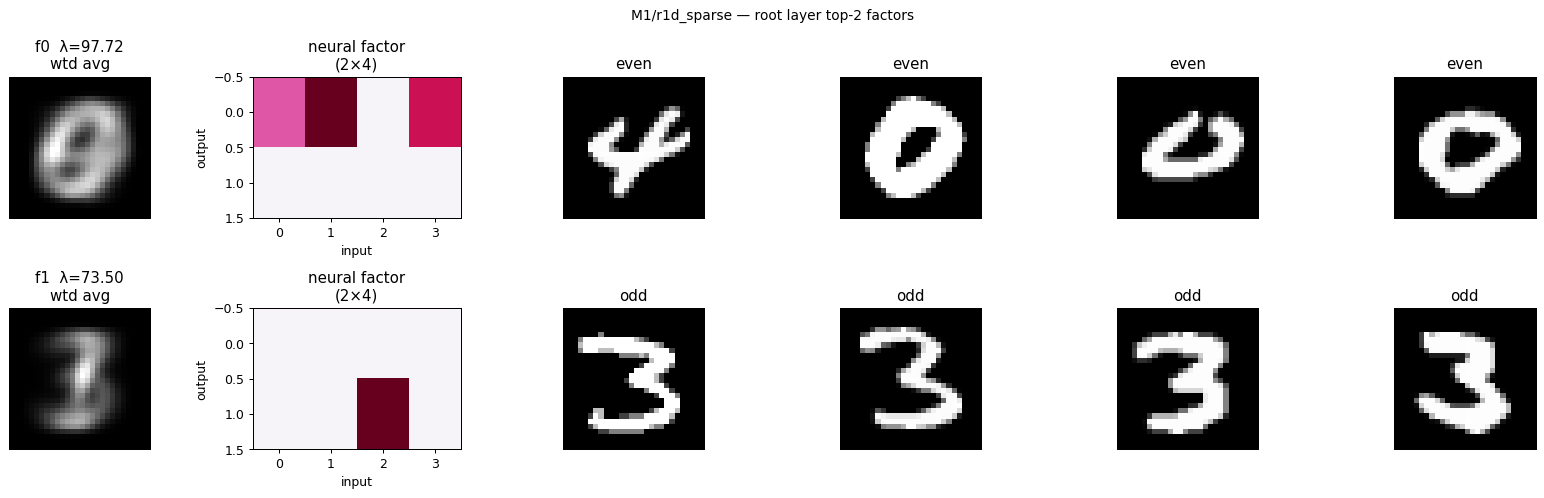

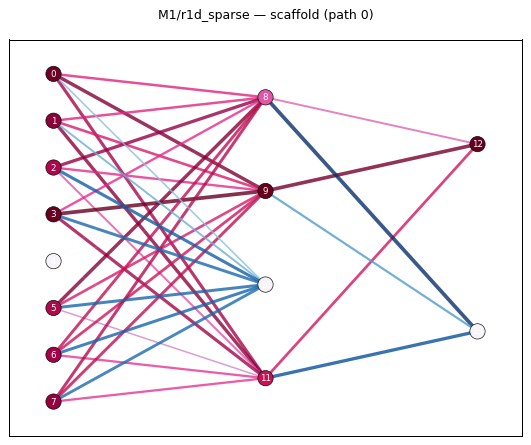

=== r1d_sparse2 ===


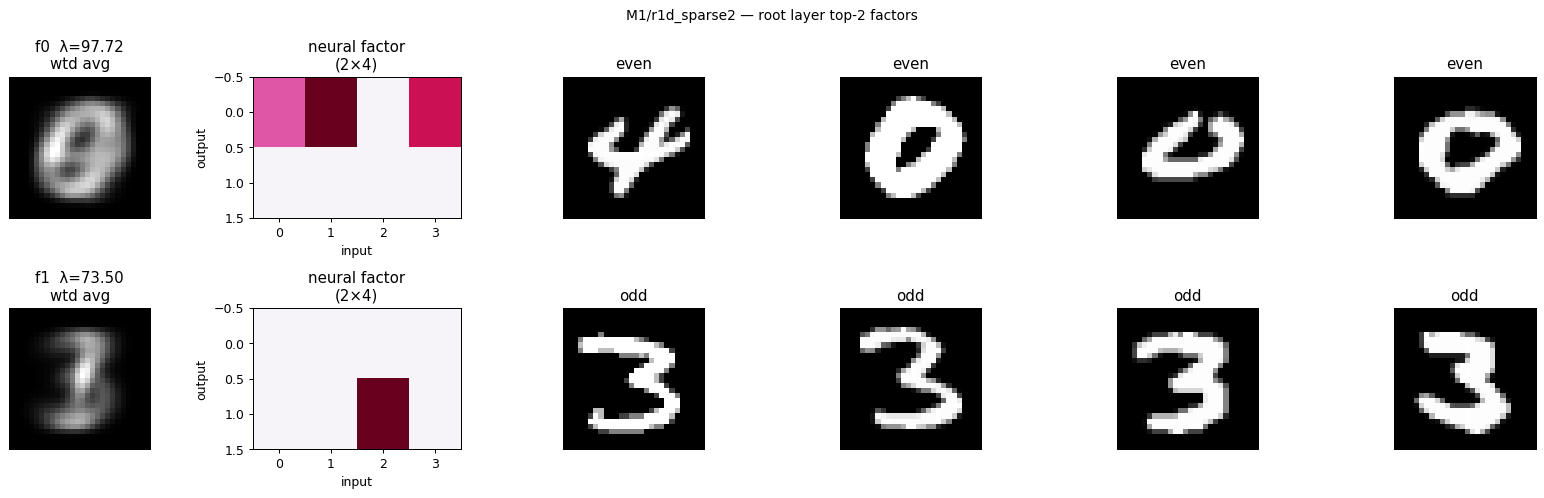

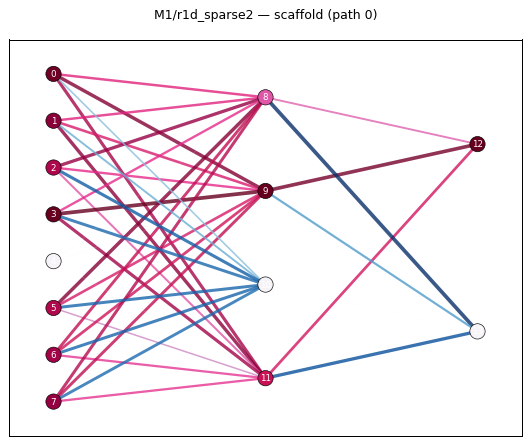

In [10]:
# §C: Qualitative — top-2 factor panels and scaffold per NMF
for v in NMF_VARIANTS:
    print(f'=== {v} ===')
    viz_top_factors(m1_bft_trees[v], m1_images, m1_targets, M1_CLASS_NAMES,
                    n_factors=2, variant_name=f'M1/{v}')
    viz_scaffold(m1_bft_trees[v], M1_LAYER_SIZES, variant_name=f'M1/{v}')

Running per-class specificity ablation for M1 (all 4 NMF variants)...
  [sklearn] ratio=1.259  per-layer={'L2': 6.611248824086413, 'L1': -23.41055119456151, 'L0': 1.3337309269691755}
  [r1d] ratio=1.000  per-layer={'L2': -2.1621849736439773, 'L1': -10.198272120760095, 'L0': 6.662356536892429}
  [r1d_sparse] ratio=1.000  per-layer={'L2': 6.611248824086413, 'L1': -12.286534002368537, 'L0': 16.452233178729767}
  [r1d_sparse2] ratio=1.000  per-layer={'L2': 6.611248824086413, 'L1': -12.286534002368537, 'L0': 16.452233178729767}


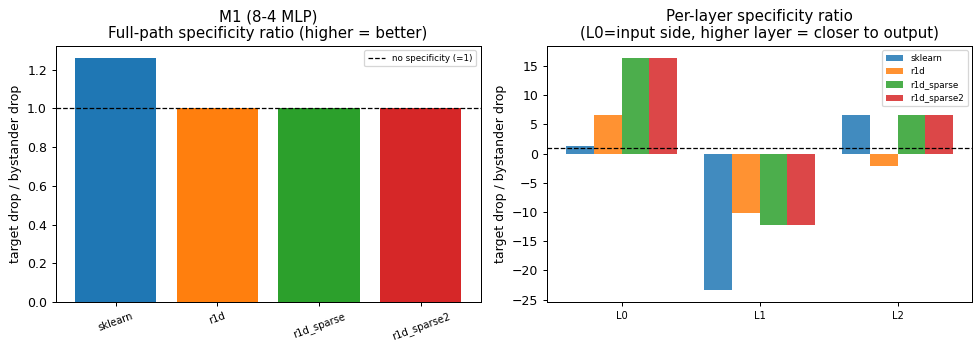


M1 (8-4 MLP) specificity summary:
    variant  ratio_full      L0       L1      L2
    sklearn      1.2593  1.3337 -23.4106  6.6112
        r1d      1.0000  6.6624 -10.1983 -2.1622
 r1d_sparse      1.0000 16.4522 -12.2865  6.6112
r1d_sparse2      1.0000 16.4522 -12.2865  6.6112


In [11]:
# §D: Per-class specificity ablation for M1 (2 classes: even/odd)
print('Running per-class specificity ablation for M1 (all 4 NMF variants)...')
m1_spec = run_per_class_ablation(
    m1_model, m1_layer_inputs, m1_targets, m1_test_loader,
    label_transform=label_transform_even_odd, fast=False)

m1_spec_df = plot_spec_results(m1_spec, title_prefix='M1 (8-4 MLP)')

# Save summary rows (replace old ablation_auc with specificity_ratio_full)
for v in NMF_VARIANTS:
    sr = m1_spec.get(v, {}).get('ratio_full', float('nan'))
    SUMMARY_ROWS.append({
        'model': 'M1 (8-4 MLP)', 'variant': v,
        'bft_time_s': round(m1_bft_times[v], 1),
        'k_star_root': int(m1_layer_bench[-1][v]['k_star']),
        'recon@k_star': round(float(m1_layer_bench[-1][v]['recon_curve'][m1_layer_bench[-1][v]['k_star']-1]), 4),
        'hung_sim_root': round(float(m1_df[(m1_df['layer'] == m1_layer_names[-1]) & (m1_df['variant'] == v)]['hung_sim_avg'].values[0]) if len(m1_df[(m1_df['layer'] == m1_layer_names[-1]) & (m1_df['variant'] == v)]) else 0, 4),
        'specificity_ratio': round(sr, 4) if not np.isnan(sr) else float('nan'),
    })


---
## §2  MNIST Digit MLP — 40-20 hidden units, 10-class classification

In [12]:
M2_DIR = '../experiments/mnist_digit_mlp_40_20'
m2_model, m2_cfg = load_experiment(M2_DIR, device)
print(m2_cfg)

_, m2_test_ds = get_mnist_loaders(batch_size=256, root='../data/')
m2_test_loader = torch.utils.data.DataLoader(m2_test_ds.dataset, batch_size=256, shuffle=False)

m2_data = collect_layer_inputs(
    m2_model, m2_test_ds.dataset,
    label_transform=None, device=device)

m2_images        = m2_data['images']
m2_targets       = m2_data['targets']     # 0-9 digit labels
m2_digits        = m2_data['digits']
m2_layer_inputs  = m2_data['layer_inputs']
M2_CLASS_NAMES   = {d: str(d) for d in range(10)}
M2_LAYER_SIZES   = list(m2_cfg['arch_kwargs']['hidden_dims']) + [m2_cfg['arch_kwargs']['output_dim']]

print(f'Samples: {len(m2_targets)}  Layer sizes: {M2_LAYER_SIZES}')

{'arch': 'SimpleMLP', 'arch_kwargs': {'input_dim': 784, 'hidden_dims': [40, 20], 'output_dim': 10}, 'dataset': 'MNIST', 'dataset_kwargs': {'batch_size': 32, 'root': '../data/'}, 'label_transform': 'identity', 'analysis_layer_indices': [2, 4, 6], 'n_per_class': 1000, 'input_side': 28, 'description': 'SimpleMLP 784->40->20->10 on MNIST digit classification'}
Samples: 9560  Layer sizes: [40, 20, 10]


In [13]:
m2_arbors = []
m2_layer_names = []
lin_idxs = m2_model.linear_layer_indices()
for li_pos, lin_idx in enumerate(lin_idxs):
    W   = m2_model.layers[lin_idx].weight.detach().cpu().numpy()
    act = m2_layer_inputs[li_pos]
    J   = compute_joint_arbors_normalized(W, act)
    m2_arbors.append(np.clip(J, 0, None))
    m2_layer_names.append(f'L{li_pos+1} ({W.shape[0]}×{W.shape[1]})')
    print(f'  Layer {li_pos+1}: W={W.shape}  J={J.shape}')

  Layer 1: W=(40, 784)  J=(9560, 31360)
  Layer 2: W=(20, 40)  J=(9560, 800)
  Layer 3: W=(10, 20)  J=(9560, 200)


Running per-layer NMF benchmarks for M2 (may take a few minutes)...
  Layer 1/3 done
  Layer 2/3 done
  Layer 3/3 done


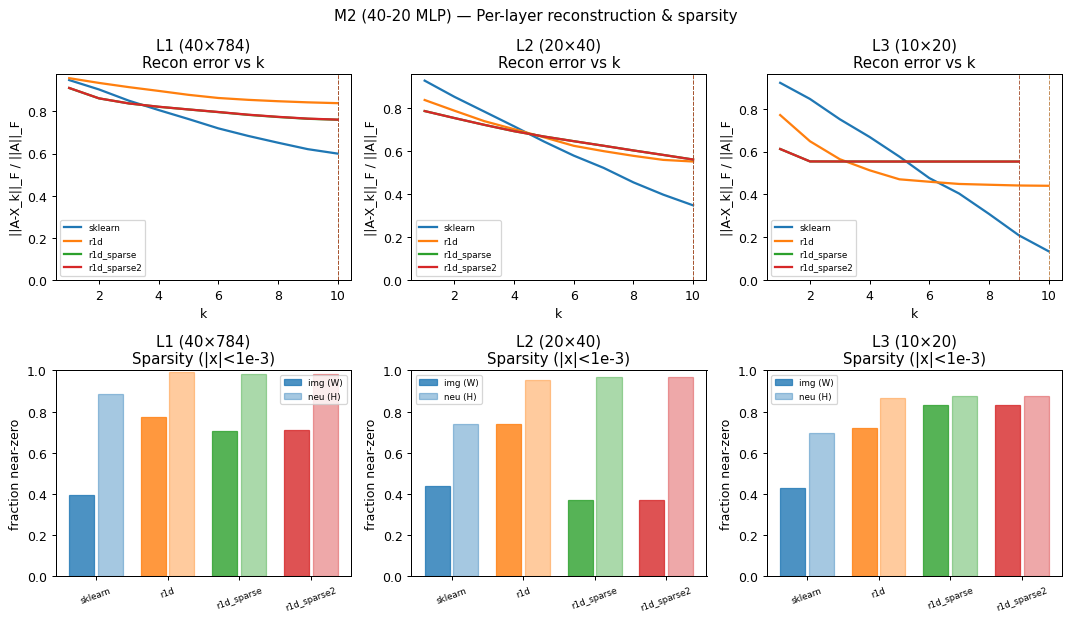

In [14]:
print('Running per-layer NMF benchmarks for M2 (may take a few minutes)...')
m2_layer_bench = []
for li, J in enumerate(m2_arbors):
    print(f'  Layer {li+1}/{len(m2_arbors)}', end=' ')
    bench = run_layer_benchmark(J, k_max=K_MAX_BENCH)
    m2_layer_bench.append(bench)
    print('done')

plot_layer_recon_sparsity(m2_layer_bench, m2_layer_names, title_prefix='M2 (40-20 MLP)')

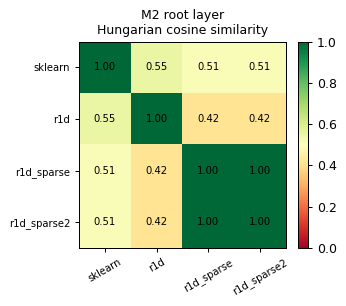

In [15]:
plot_hung_heatmap(m2_layer_bench[-1], title='M2 root layer')

In [16]:
print('Running BFT for all 4 NMF variants on M2...')
# n_branches=1 for M2: the 40x784 input-layer arbor (31360-dim) is large;
# branching exponentially multiplies NMF calls — single path still gives full scaffold.
m2_bft_trees = {}
m2_bft_times = {}
for v in NMF_VARIANTS:
    print(f'  {v}...', end=' ', flush=True)
    t0 = time.perf_counter()
    m2_bft_trees[v] = bft(
        m2_model, m2_layer_inputs,
        k_max=K_MAX_BFT, n_branches=1,
        factorizer=v, verbose=0)
    m2_bft_times[v] = time.perf_counter() - t0
    print(f'{m2_bft_times[v]:.1f}s')

m2_df = print_quant_table(m2_layer_bench, m2_layer_names, m2_bft_times, 'M2')


Running BFT for all 4 NMF variants on M2...
  sklearn... 201.0s
  r1d... 71.9s
  r1d_sparse... 28.9s
  r1d_sparse2... 33.5s

M2 — Quantitative summary
      layer     variant  layer_time_s  k_star  recon@k_star  hung_sim_avg  sparsity_neu
L1 (40×784)     sklearn        50.114      10        0.5999        0.5456        0.8851
L1 (40×784)         r1d        19.178      10        0.8386        0.5164        0.9947
L1 (40×784)  r1d_sparse        13.150      10        0.7602        0.6818        0.9825
L1 (40×784) r1d_sparse2        21.854      10        0.7607        0.6898        0.9822
 L2 (20×40)     sklearn         0.441      10        0.3479        0.5845        0.7396
 L2 (20×40)         r1d         0.428      10        0.5512        0.6484        0.9536
 L2 (20×40)  r1d_sparse         0.706      10        0.5605        0.7361        0.9669
 L2 (20×40) r1d_sparse2         0.829      10        0.5605        0.7361        0.9669
 L3 (10×20)     sklearn         0.224      10        0.13

=== sklearn ===


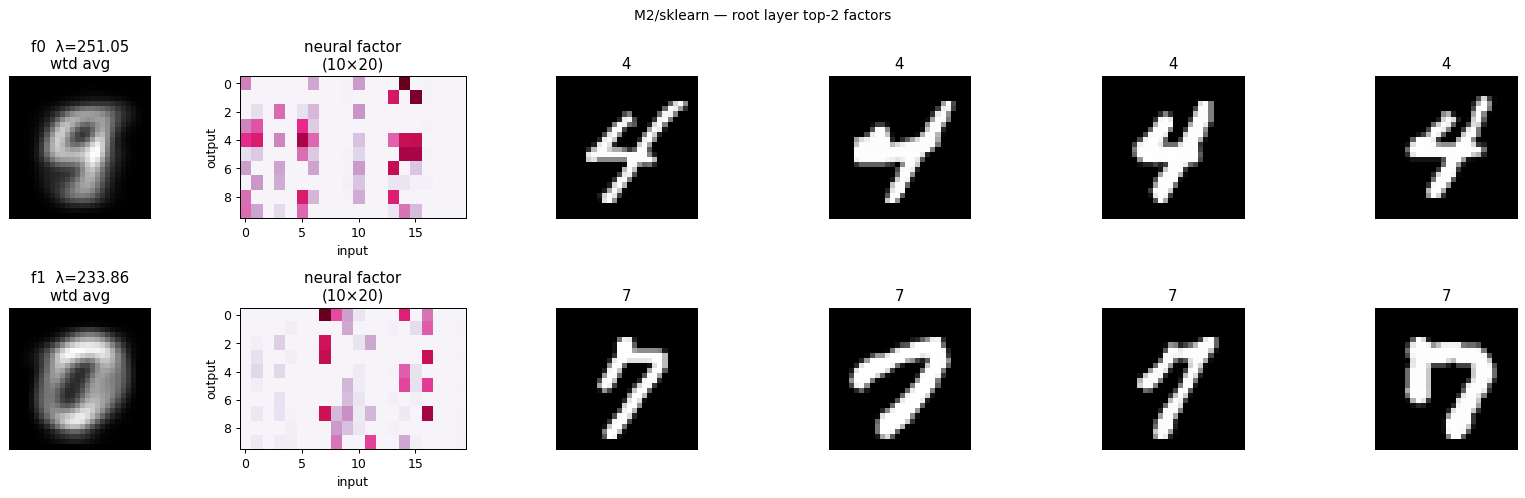

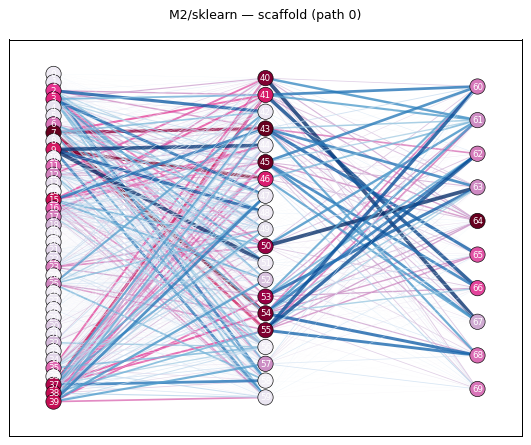

=== r1d ===


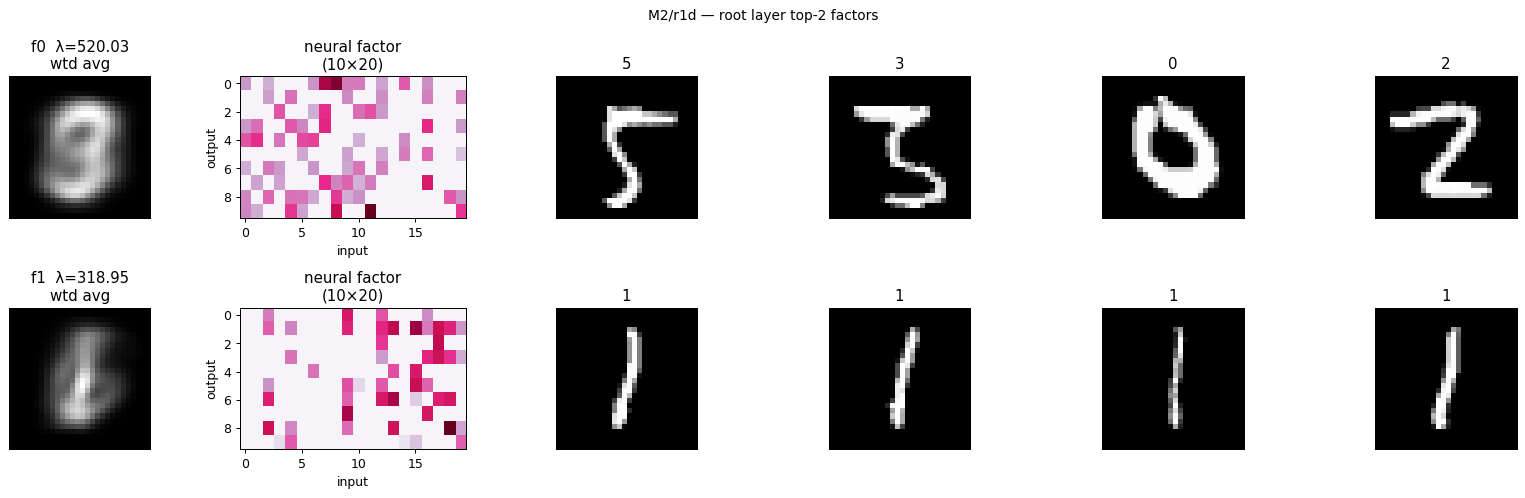

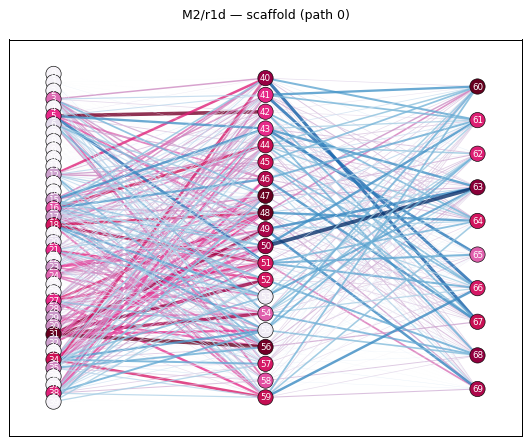

=== r1d_sparse ===


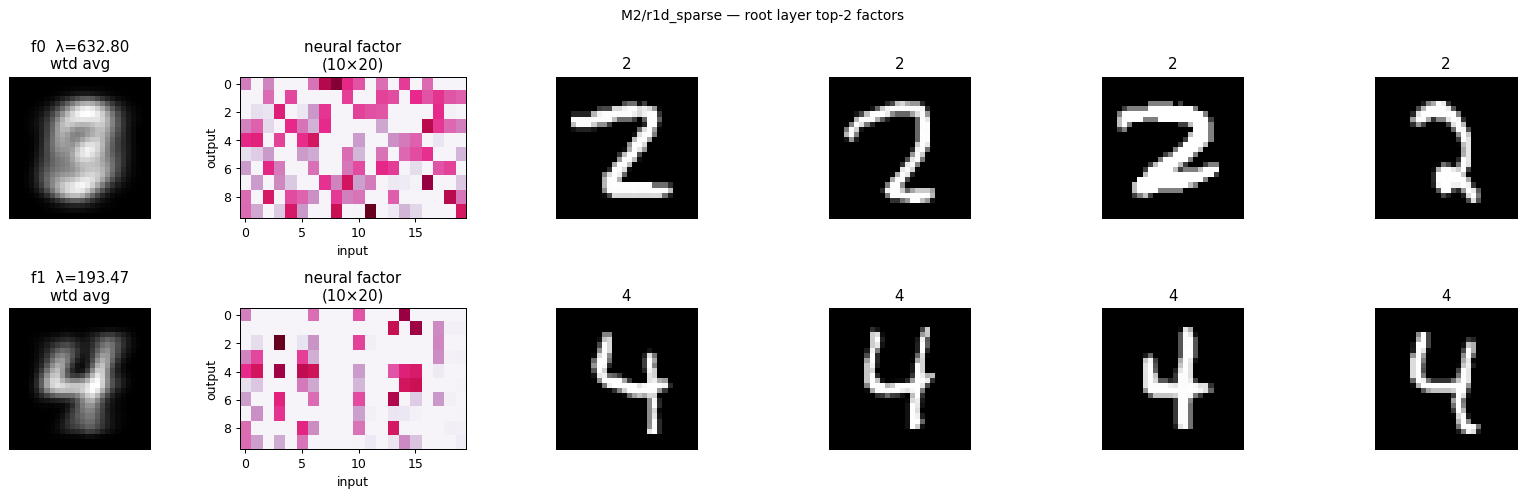

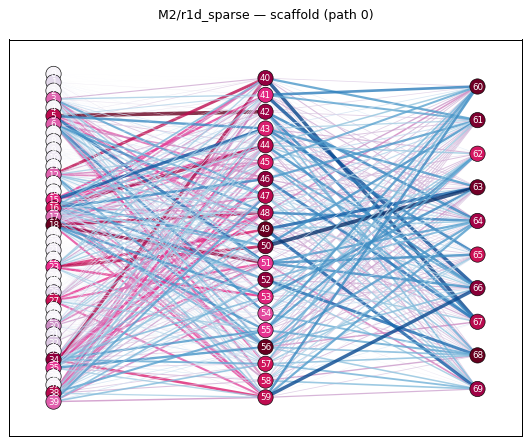

=== r1d_sparse2 ===


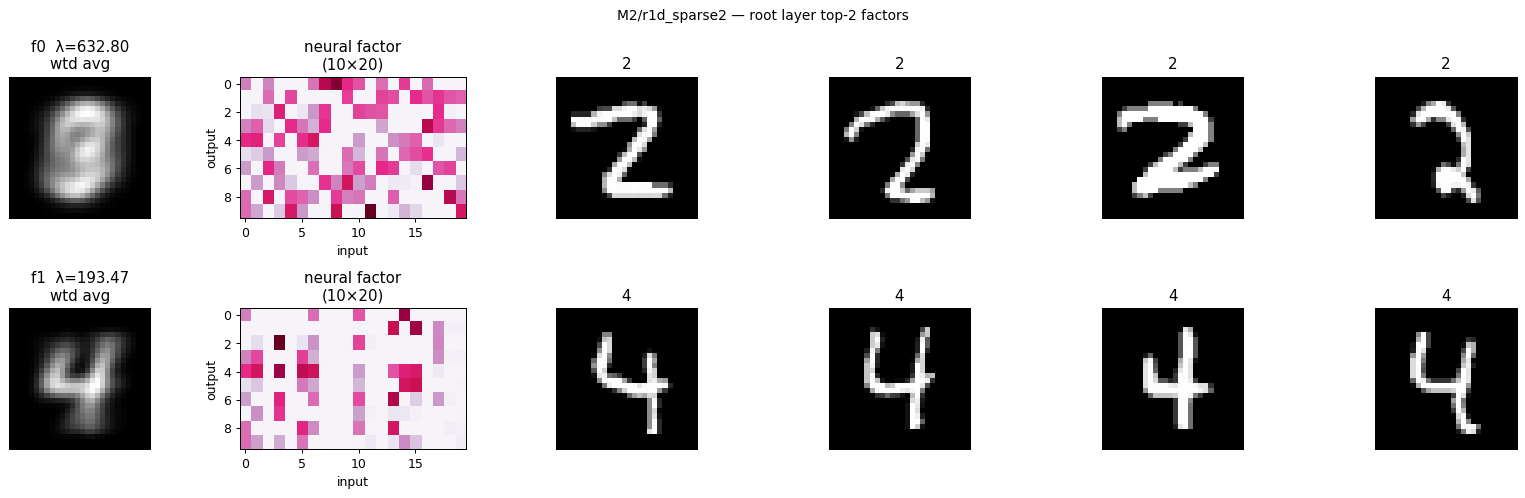

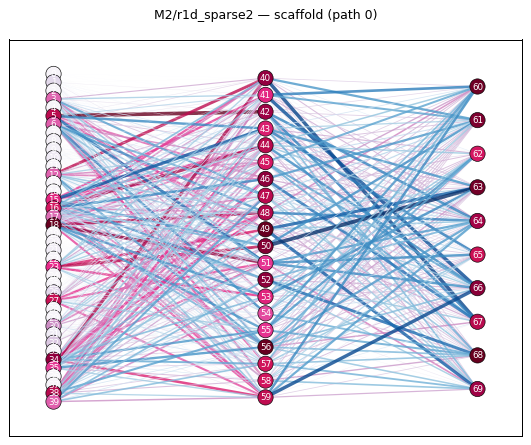

In [17]:
for v in NMF_VARIANTS:
    print(f'=== {v} ===')
    viz_top_factors(m2_bft_trees[v], m2_images, m2_targets, M2_CLASS_NAMES,
                    n_factors=2, variant_name=f'M2/{v}')
    viz_scaffold(m2_bft_trees[v], M2_LAYER_SIZES, variant_name=f'M2/{v}')

Running per-class specificity ablation for M2 (sklearn + r1d_sparse, fast mode)...


  [sklearn] ratio=1.222  per-layer={'L2': 4.924755942470996, 'L1': 3.5721852278055968, 'L0': 1.6959313201057835}
  [r1d_sparse] ratio=1.021  per-layer={'L2': 4.488364554598472, 'L1': 4.427324609973821, 'L0': 2.0965241915725716}


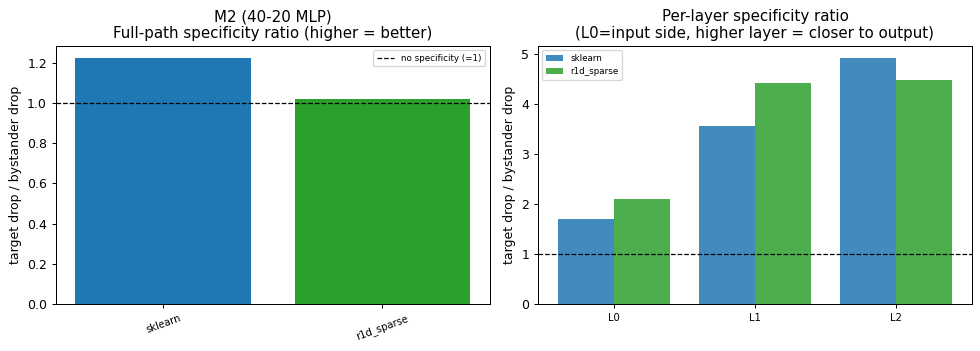


M2 (40-20 MLP) specificity summary:
   variant  ratio_full     L0     L1     L2
   sklearn      1.2220 1.6959 3.5722 4.9248
r1d_sparse      1.0211 2.0965 4.4273 4.4884


In [18]:
# §D: Per-class specificity ablation for M2 (10 classes: digits 0-9)
# fast=True: sklearn + r1d_sparse only, subsample 300 samples/class
print('Running per-class specificity ablation for M2 (sklearn + r1d_sparse, fast mode)...')
m2_spec = run_per_class_ablation(
    m2_model, m2_layer_inputs, m2_targets, m2_test_loader,
    label_transform=None, fast=True)

m2_spec_df = plot_spec_results(m2_spec, title_prefix='M2 (40-20 MLP)')

# Fill in NaN for variants not run in fast mode
for v in NMF_VARIANTS:
    sr = m2_spec.get(v, {}).get('ratio_full', float('nan'))
    SUMMARY_ROWS.append({
        'model': 'M2 (40-20 MLP)', 'variant': v,
        'bft_time_s': round(m2_bft_times[v], 1),
        'k_star_root': int(m2_layer_bench[-1][v]['k_star']),
        'recon@k_star': round(float(m2_layer_bench[-1][v]['recon_curve'][m2_layer_bench[-1][v]['k_star']-1]), 4),
        'hung_sim_root': round(float(m2_df[(m2_df['layer'] == m2_layer_names[-1]) & (m2_df['variant'] == v)]['hung_sim_avg'].values[0]) if len(m2_df[(m2_df['layer'] == m2_layer_names[-1]) & (m2_df['variant'] == v)]) else 0, 4),
        'specificity_ratio': round(sr, 4) if not np.isnan(sr) else float('nan'),
    })


---
## §3  CIFAR-10 CNN — SmallCNN (nb04 checkpoint)

In [19]:
# SmallCNN exactly as in nb04 (must match checkpoint architecture)
class SmallCNN_NB04(nn.Module):
    """3-conv + 2-FC CIFAR-10 classifier (nb04 checkpoint architecture)."""
    def __init__(self):
        super().__init__()
        self.conv1   = nn.Conv2d(3,  8, 3, padding=1)
        self.bn1     = nn.BatchNorm2d(8)
        self.conv2   = nn.Conv2d(8, 16, 3, padding=1)
        self.bn2     = nn.BatchNorm2d(16)
        self.conv3   = nn.Conv2d(16, 32, 3, padding=1)
        self.bn3     = nn.BatchNorm2d(32)
        self.pool    = nn.MaxPool2d(2)
        self.avgpool = nn.AdaptiveAvgPool2d(4)
        self.fc1     = nn.Linear(32 * 4 * 4, 32)
        self.fc2     = nn.Linear(32, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.avgpool(F.relu(self.bn3(self.conv3(x))))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return F.log_softmax(self.fc2(x), dim=1)


M3_WEIGHTS = '../data/cache/nb04/weights/weights.pt'
m3_model = SmallCNN_NB04().to(device)
m3_model.load_state_dict(torch.load(M3_WEIGHTS, map_location=device, weights_only=True))
m3_model.eval()
print(f'Loaded CNN from {M3_WEIGHTS}')
print(f'Parameters: {sum(p.numel() for p in m3_model.parameters()):,}')

Loaded CNN from ../data/cache/nb04/weights/weights.pt
Parameters: 22,890


In [20]:
import torchvision.transforms as T
import torchvision.datasets as tv_datasets

_mean = (0.4914, 0.4822, 0.4465); _std = (0.2470, 0.2435, 0.2616)
_test_tfm = T.Compose([T.ToTensor(), T.Normalize(_mean, _std)])
_cifar_test = tv_datasets.CIFAR10('../data/', train=False, download=True, transform=_test_tfm)
m3_test_loader = torch.utils.data.DataLoader(_cifar_test, batch_size=128, shuffle=False)

CIFAR_CLASSES = {i: c for i, c in enumerate(
    ['airplane','automobile','bird','cat','deer',
     'dog','frog','horse','ship','truck'])}

print('Collecting layer data for CNN...')
m3_raw = collect_layer_data(m3_model, m3_test_loader, device)
m3_images  = m3_raw['images']   # (N, 3, 32, 32)  normalized
m3_targets = m3_raw['targets']  # (N,) class indices
m3_ldata   = m3_raw['layer_data']  # list of {name, type, weight, input_fmap, output_fmap}
print(f'Collected {len(m3_targets)} correctly-classified samples')
for ld in m3_ldata:
    print(f"  {ld['name']:<12} {ld['type']:<5} W:{ld['weight'].shape}  in:{ld['input_fmap'].shape}")

Collected 7918 correctly-classified samples
  conv1        conv  W:(8, 3, 3, 3)  in:(7918, 3, 32, 32)
  conv2        conv  W:(16, 8, 3, 3)  in:(7918, 8, 16, 16)
  conv3        conv  W:(32, 16, 3, 3)  in:(7918, 16, 8, 8)
  fc1          fc    W:(32, 512)  in:(7918, 512)
  fc2          fc    W:(10, 32)  in:(7918, 32)


In [21]:
# Pre-compute per-layer joint arbors
m3_arbors = []
m3_layer_names = []
for ld in m3_ldata:
    W = ld['weight']
    if ld['type'] == 'conv':
        J = compute_conv_joint_arbors(W, ld['input_fmap'], pool_method='avg')
    else:
        J = compute_joint_arbors_normalized(W, ld['input_fmap'])
    m3_arbors.append(np.clip(J, 0, None))
    m3_layer_names.append(f"{ld['name']} ({ld['type']})")
    print(f"  {ld['name']}: W={W.shape}  J={J.shape}")

  conv1: W=(8, 3, 3, 3)  J=(7918, 216)
  conv2: W=(16, 8, 3, 3)  J=(7918, 1152)
  conv3: W=(32, 16, 3, 3)  J=(7918, 4608)
  fc1: W=(32, 512)  J=(7918, 16384)
  fc2: W=(10, 32)  J=(7918, 320)


Running per-layer NMF benchmarks for M3 CNN...
  Layer 1/5 conv1 (conv) done
  Layer 2/5 conv2 (conv) done
  Layer 3/5 conv3 (conv) done
  Layer 4/5 fc1 (fc) done
  Layer 5/5 fc2 (fc) done


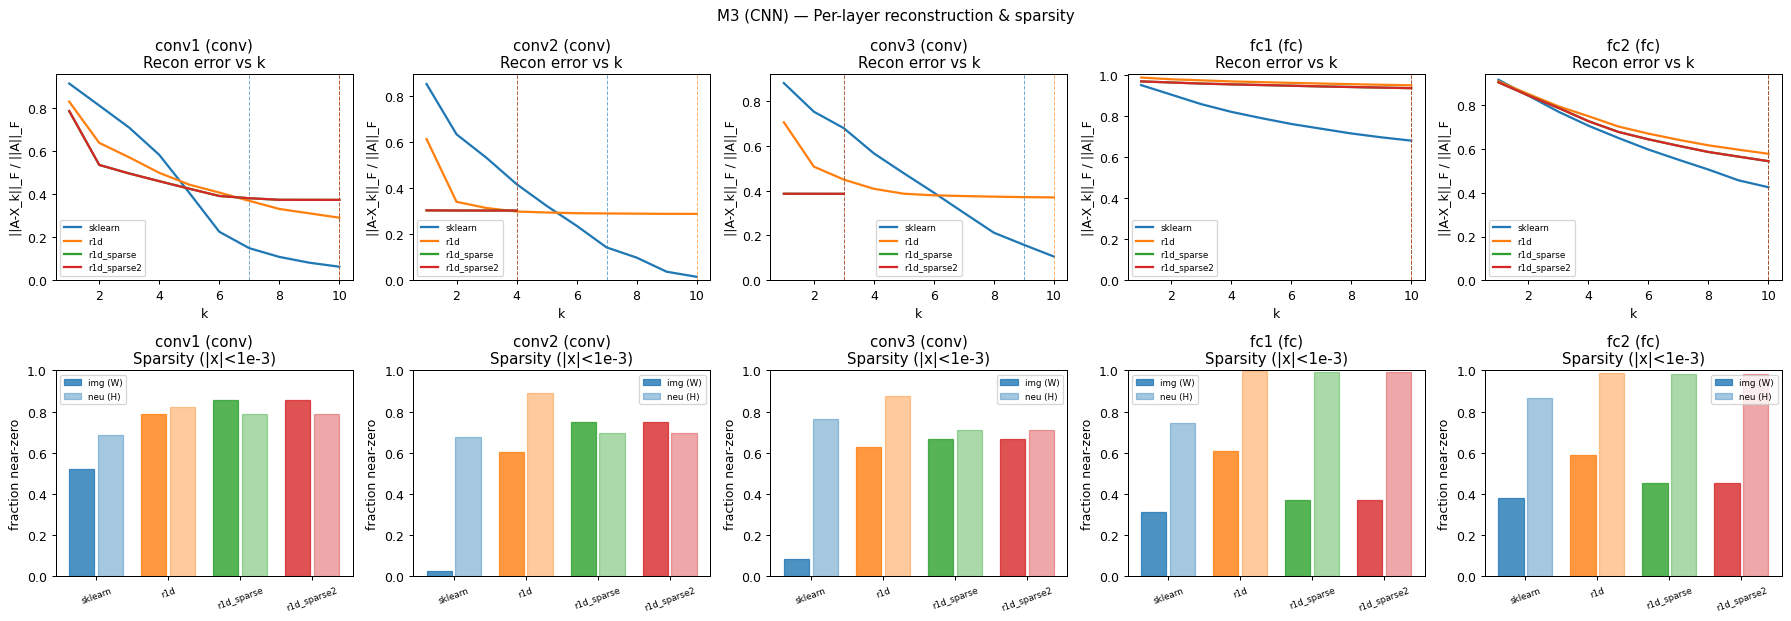

In [22]:
print('Running per-layer NMF benchmarks for M3 CNN...')
m3_layer_bench = []
for li, J in enumerate(m3_arbors):
    print(f'  Layer {li+1}/{len(m3_arbors)} {m3_layer_names[li]}', end=' ')
    bench = run_layer_benchmark(J, k_max=K_MAX_BENCH)
    m3_layer_bench.append(bench)
    print('done')

plot_layer_recon_sparsity(m3_layer_bench, m3_layer_names, title_prefix='M3 (CNN)')

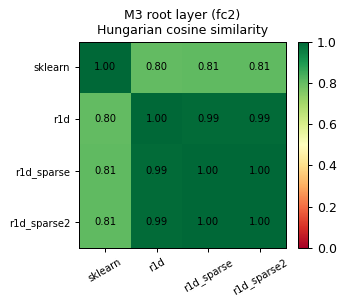

In [23]:
# Plot Hungarian similarity for the last (fc2) layer
plot_hung_heatmap(m3_layer_bench[-1], title='M3 root layer (fc2)')

In [ ]:
print('Running BFT for all 4 NMF variants on M3 CNN...')
m3_bft_trees = {}
m3_bft_times = {}
for v in NMF_VARIANTS:
    print(f'  {v}...', end=' ', flush=True)
    t0 = time.perf_counter()
    m3_bft_trees[v] = bft(
        m3_ldata,  # layer-dict mode
        k_max=K_MAX_BFT, n_branches=2,
        conv_pool_method='avg',
        factorizer=v, verbose=0)
    m3_bft_times[v] = time.perf_counter() - t0
    print(f'{m3_bft_times[v]:.1f}s')

m3_df = print_quant_table(m3_layer_bench, m3_layer_names, m3_bft_times, 'M3')

Running BFT for all 4 NMF variants on M3 CNN...
  sklearn... 

In [ ]:
# Denormalize CIFAR images for display
_m = np.array(_mean)[None, :, None, None]
_s = np.array(_std)[None, :, None, None]
m3_images_disp = np.clip(m3_images * _s + _m, 0, 1)  # (N, 3, 32, 32)

for v in NMF_VARIANTS:
    print(f'=== {v} ===')
    viz_top_factors(m3_bft_trees[v], m3_images_disp, m3_targets, CIFAR_CLASSES,
                    n_factors=2, variant_name=f'M3/{v}', is_mnist=False)
    viz_scaffold(m3_bft_trees[v], None, variant_name=f'M3/{v}')

In [ ]:
# §D: Per-class specificity ablation for M3 (CNN, 10 CIFAR classes)
# Uses sklearn + r1d_sparse only (fast=True) and subsamples 300 per class.
# CNN-specific ablation: weight keys (l_idx, i, j) are zeroed via named submodules.

import copy as _copy

def ablate_cnn_model(model_orig, ldata, weight_keys_to_zero):
    """Deepcopy model_orig and zero the (layer_idx, i, j) weights specified.

    For conv layers j indexes the flattened (C_in, kH, kW) dimension.
    For fc  layers j indexes the input-neuron dimension directly.
    """
    model = _copy.deepcopy(model_orig)
    model.eval()
    with torch.no_grad():
        for l_idx, i, j in weight_keys_to_zero:
            name  = ldata[l_idx]['name']
            ltype = ldata[l_idx]['type']
            mod   = model.get_submodule(name)
            if ltype == 'conv':
                C_in = mod.weight.shape[1]
                kH   = mod.weight.shape[2]
                kW   = mod.weight.shape[3]
                c_in = j // (kH * kW)
                rem  = j  % (kH * kW)
                kh   = rem // kW
                kw   = rem  % kW
                mod.weight[i, c_in, kh, kw] = 0.0
            else:
                mod.weight[i, j] = 0.0
    return model


def run_per_class_ablation_cnn(model, ldata, targets, test_loader, fast=True):
    """Per-class specificity ablation for CNN (layer-dict BFT mode).

    Mirrors run_per_class_ablation but uses ablate_cnn_model and filters
    ldata by class rather than filtering layer_inputs.
    """
    classes  = sorted(int(c) for c in np.unique(targets).tolist())
    variants = ['sklearn', 'r1d_sparse'] if fast else NMF_VARIANTS

    baseline = per_class_accuracy(model, test_loader, None, device)

    def _first_path(tree):
        path, node = [], tree
        while node:
            path.append(node)
            node = node['children'][0] if node['children'] else None
        return path

    def _eval_drop(model_orig, keys):
        m_abl = ablate_cnn_model(model_orig, ldata, keys)
        accs  = per_class_accuracy(m_abl, test_loader, None, device)
        return {c: baseline.get(c, 1.0) - accs.get(c, 0.0) for c in classes}

    all_results = {}
    for v in variants:
        print(f'  [{v}]', end=' ', flush=True)
        full_targets, full_bystanders = [], []
        layer_t = {}; layer_b = {}

        for d in classes:
            idx_d = np.where(targets == d)[0]
            if fast and len(idx_d) > 300:
                idx_d = np.random.choice(idx_d, 300, replace=False)
            ldata_d = [
                {**ld,
                 'input_fmap':  ld['input_fmap'][idx_d],
                 'output_fmap': ld['output_fmap'][idx_d]}
                for ld in ldata
            ]
            tree_d = bft(ldata_d, k_max=K_MAX_BFT, n_branches=1,
                         conv_pool_method='avg', factorizer=v, verbose=0)
            path = _first_path(tree_d)

            # (a) Full-path ablation
            full_scores = extract_importance_scores(path)
            ft_list, fb_list = [], []
            for frac in SPEC_FRACS:
                n_k = max(1, int(frac * len(full_scores)))
                top_keys = sorted(full_scores, key=full_scores.get, reverse=True)[:n_k]
                drops = _eval_drop(model, top_keys)
                ft_list.append(drops[d])
                fb_list.append(np.mean([drops[c] for c in classes if c != d]))
            full_targets.append(np.mean(ft_list))
            full_bystanders.append(np.mean(fb_list))

            # (b) Per-layer ablation along path
            for node in path:
                lname = f'L{node["layer_idx"]}'
                node_scores = extract_importance_scores([node])
                if not node_scores:
                    continue
                lt_list, lb_list = [], []
                for frac in SPEC_FRACS:
                    n_k = max(1, int(frac * len(node_scores)))
                    top_keys = sorted(node_scores, key=node_scores.get, reverse=True)[:n_k]
                    drops = _eval_drop(model, top_keys)
                    lt_list.append(drops[d])
                    lb_list.append(np.mean([drops[c] for c in classes if c != d]))
                layer_t.setdefault(lname, []).append(np.mean(lt_list))
                layer_b.setdefault(lname, []).append(np.mean(lb_list))

        ratio_full = float(np.mean(full_targets) / (np.mean(full_bystanders) + 1e-9))
        layer_ratios = {
            ln: float(np.mean(layer_t[ln]) / (np.mean(layer_b[ln]) + 1e-9))
            for ln in layer_t
        }
        layer_names = sorted(layer_t.keys())
        print(f'ratio={ratio_full:.3f}  per-layer={layer_ratios}')
        all_results[v] = dict(
            ratio_full=ratio_full,
            full_targets=full_targets,
            full_bystanders=full_bystanders,
            layer_ratios=layer_ratios,
            layer_names=layer_names,
        )

    return all_results


print('Running per-class specificity ablation for M3 CNN (sklearn + r1d_sparse, fast mode)...')
m3_spec = run_per_class_ablation_cnn(
    m3_model, m3_ldata, m3_targets, m3_test_loader, fast=True)

m3_spec_df = plot_spec_results(m3_spec, title_prefix='M3 (CNN CIFAR-10)')

# Save summary rows for M3
for v in NMF_VARIANTS:
    sr = m3_spec.get(v, {}).get('ratio_full', float('nan'))
    SUMMARY_ROWS.append({
        'model': 'M3 (CNN)', 'variant': v,
        'bft_time_s': round(m3_bft_times[v], 1),
        'k_star_root': int(m3_layer_bench[-1][v]['k_star']),
        'recon@k_star': round(float(m3_layer_bench[-1][v]['recon_curve'][m3_layer_bench[-1][v]['k_star']-1]), 4),
        'hung_sim_root': round(float(m3_df[(m3_df['layer'] == m3_layer_names[-1]) & (m3_df['variant'] == v)]['hung_sim_avg'].values[0]) if len(m3_df[(m3_df['layer'] == m3_layer_names[-1]) & (m3_df['variant'] == v)]) else 0, 4),
        'specificity_ratio': round(sr, 4) if not np.isnan(sr) else float('nan'),
    })

---
## §4  Tiny ViT — MNIST even/odd (1-block transformer)

> Requires `experiments/mnist_even_odd_vit_tiny/weights.pt`.
> Run notebook 05 first if missing.

In [ ]:
# TinyViT architecture (must match nb05 exactly)
class PatchEmbedder(nn.Module):
    def __init__(self, img_size=28, patch_size=7, embed_dim=32):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches  = (img_size // patch_size) ** 2
        self.proj = nn.Linear(patch_size * patch_size, embed_dim)
    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        x = x.unfold(2, p, p).unfold(3, p, p).contiguous().view(B, -1, p * p)
        return self.proj(x)

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=32, n_heads=2, ffn_dim=64):
        super().__init__()
        self.ln1  = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, n_heads, batch_first=True)
        self.ln2  = nn.LayerNorm(embed_dim)
        self.ffn1 = nn.Linear(embed_dim, ffn_dim)
        self.ffn2 = nn.Linear(ffn_dim, embed_dim)
        self._capture = False
        self._attn_in = self._attn_w = self._attn_out = None
        self._ffn1_in = self._ffn2_in = None
    def forward(self, x):
        h = self.ln1(x)
        if self._capture: self._attn_in = h.detach()
        attn_out, attn_w = self.attn(h, h, h, need_weights=self._capture,
                                     average_attn_weights=False)
        if self._capture:
            self._attn_w   = attn_w.detach()
            self._attn_out = attn_out.detach()
        x = x + attn_out
        h = self.ln2(x)
        if self._capture: self._ffn1_in = h.detach()
        h2 = F.gelu(self.ffn1(h))
        if self._capture: self._ffn2_in = h2.detach()
        x = x + self.ffn2(h2)
        return x

class TinyViT(nn.Module):
    def __init__(self, embed_dim=32, n_heads=2, ffn_dim=64, n_classes=2):
        super().__init__()
        self.patch_embed = PatchEmbedder(embed_dim=embed_dim)
        T = self.patch_embed.n_patches + 1
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, T, embed_dim))
        self.block = TransformerBlock(embed_dim, n_heads, ffn_dim)
        self.ln   = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, n_classes)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
    def forward(self, x, capture=False):
        self.block._capture = capture
        B = x.shape[0]
        tokens = torch.cat([self.cls_token.expand(B,-1,-1),
                            self.patch_embed(x)], dim=1) + self.pos_embed
        tokens = self.block(tokens)
        return F.log_softmax(self.head(self.ln(tokens[:, 0])), dim=1)


M4_DIR = '../experiments/mnist_even_odd_vit_tiny'
m4_model = TinyViT(embed_dim=32).to(device)
try:
    m4_model.load_state_dict(torch.load(
        os.path.join(M4_DIR, 'weights.pt'), map_location=device, weights_only=True))
    m4_model.eval()
    print('Loaded TinyViT checkpoint')
    M4_AVAILABLE = True
except FileNotFoundError:
    print('ERROR: checkpoint not found. Please run notebook 05 first to save it.')
    M4_AVAILABLE = False

NameError: name 'nn' is not defined

In [ ]:
if not M4_AVAILABLE:
    raise RuntimeError('Skipping M4 — checkpoint missing. Run nb05 first.')

_, m4_test_ds = get_mnist_loaders(batch_size=256, root='../data/')
m4_test_loader = torch.utils.data.DataLoader(m4_test_ds.dataset, batch_size=256, shuffle=False)

# Collect activations exactly as in nb05
m4_acts = {'attn_in': [], 'attn_w': [], 'attn_out_cls': [], 'ffn1_in': [], 'ffn2_in': []}
m4_images_list, m4_targets_list = [], []

m4_model.eval()
with torch.no_grad():
    for imgs, digits in m4_test_loader:
        imgs   = imgs.to(device)
        labels = label_transform_even_odd(digits)
        logits = m4_model(imgs, capture=True)
        mask   = (logits.argmax(1).cpu() == labels)
        if not mask.any(): continue
        blk = m4_model.block
        m4_acts['attn_in'].append(blk._attn_in[mask].cpu().numpy())
        m4_acts['attn_w'].append(blk._attn_w[mask].mean(1)[:, 0, :].cpu().numpy())
        m4_acts['attn_out_cls'].append(blk._attn_out[mask, 0].cpu().numpy())
        m4_acts['ffn1_in'].append(blk._ffn1_in[mask, 0].cpu().numpy())
        m4_acts['ffn2_in'].append(blk._ffn2_in[mask, 0].cpu().numpy())
        m4_images_list.append(imgs[mask].cpu().numpy())
        m4_targets_list.append(labels[mask].numpy())

for k in m4_acts:
    m4_acts[k] = np.concatenate(m4_acts[k], axis=0)
m4_images  = np.concatenate(m4_images_list,  axis=0)
m4_targets = np.concatenate(m4_targets_list, axis=0)
M4_CLASS_NAMES = {0: 'even', 1: 'odd'}

# Build layer dicts
D = 32
W_V  = m4_model.block.attn.in_proj_weight[2*D:, :].detach().cpu().numpy()
W_O  = m4_model.block.attn.out_proj.weight.detach().cpu().numpy()
W_f1 = m4_model.block.ffn1.weight.detach().cpu().numpy()
W_f2 = m4_model.block.ffn2.weight.detach().cpu().numpy()

m4_layer_dicts = [
    {'type': 'attn', 'name': 'B0-V',    'weight': W_V,
     'input_fmap': m4_acts['attn_in'], 'attn_weights': m4_acts['attn_w']},
    {'type': 'fc',   'name': 'B0-O',    'weight': W_O,
     'input_fmap': m4_acts['attn_out_cls']},
    {'type': 'fc',   'name': 'B0-FFN1', 'weight': W_f1,
     'input_fmap': m4_acts['ffn1_in']},
    {'type': 'fc',   'name': 'B0-FFN2', 'weight': W_f2,
     'input_fmap': m4_acts['ffn2_in']},
]
print(f'Collected {len(m4_targets)} correct samples')
for d in m4_layer_dicts:
    print(f"  {d['name']:<10} {d['type']:<5} W:{d['weight'].shape}")

Collected 9760 correct samples
  B0-V       attn  W:(32, 32)
  B0-O       fc    W:(32, 32)
  B0-FFN1    fc    W:(64, 32)
  B0-FFN2    fc    W:(32, 64)


In [ ]:
m4_arbors = []
m4_layer_names = []
for d in m4_layer_dicts:
    W = d['weight']
    if d['type'] == 'attn':
        J = compute_attn_joint_arbors(W, d['input_fmap'], d['attn_weights'])
    else:
        J = compute_joint_arbors_normalized(W, d['input_fmap'])
    m4_arbors.append(np.clip(J, 0, None))
    m4_layer_names.append(f"{d['name']} ({d['type']})")
    print(f"  {d['name']}: W={W.shape}  J={J.shape}")

  B0-V: W=(32, 32)  J=(9760, 1024)
  B0-O: W=(32, 32)  J=(9760, 1024)
  B0-FFN1: W=(64, 32)  J=(9760, 2048)
  B0-FFN2: W=(32, 64)  J=(9760, 2048)


Running per-layer NMF benchmarks for M4 ViT...
  Layer 1/4 B0-V (attn) done
  Layer 2/4 B0-O (fc) done
  Layer 3/4 B0-FFN1 (fc) done
  Layer 4/4 B0-FFN2 (fc) done


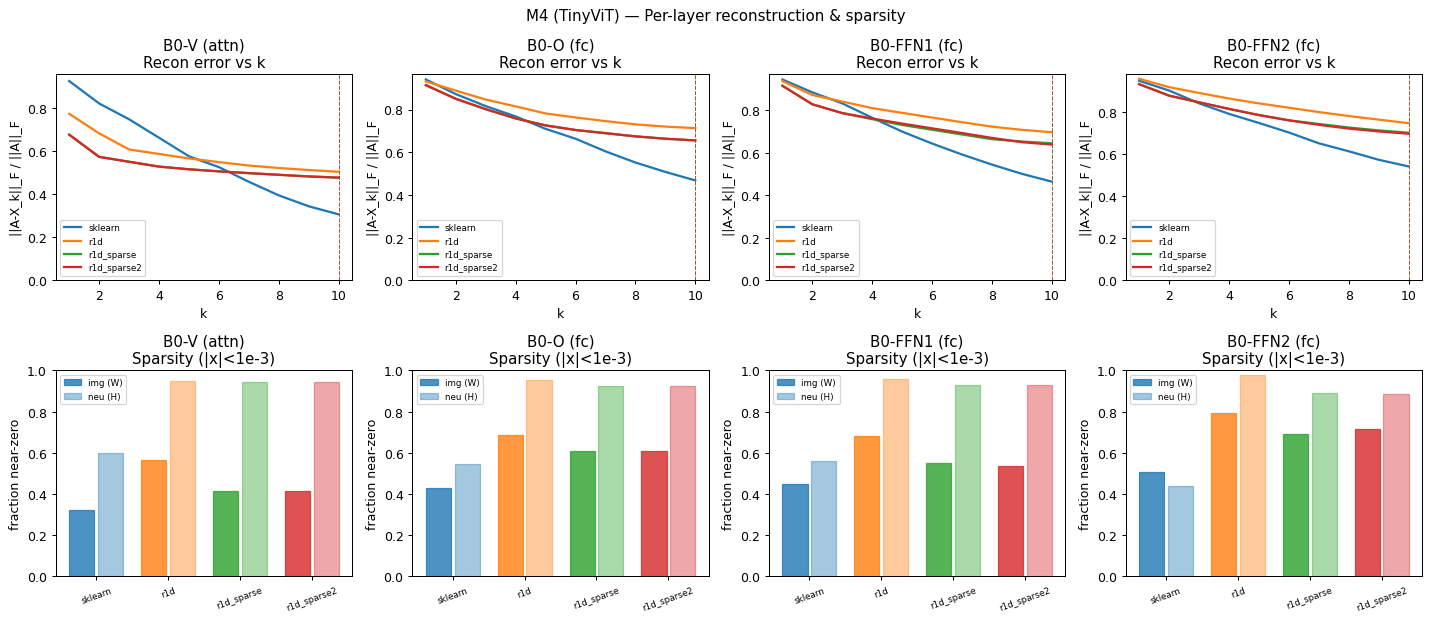

In [ ]:
print('Running per-layer NMF benchmarks for M4 ViT...')
m4_layer_bench = []
for li, J in enumerate(m4_arbors):
    print(f'  Layer {li+1}/{len(m4_arbors)} {m4_layer_names[li]}', end=' ')
    bench = run_layer_benchmark(J, k_max=K_MAX_BENCH)
    m4_layer_bench.append(bench)
    print('done')

plot_layer_recon_sparsity(m4_layer_bench, m4_layer_names, title_prefix='M4 (TinyViT)')

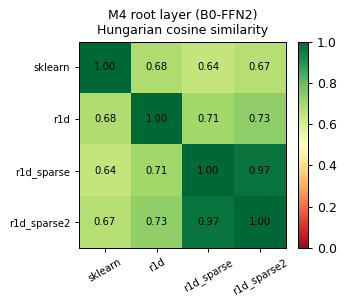

In [ ]:
plot_hung_heatmap(m4_layer_bench[-1], title='M4 root layer (B0-FFN2)')

In [ ]:
print('Running BFT for all 4 NMF variants on M4 ViT (may take several minutes)...')
m4_bft_trees = {}
m4_bft_times = {}
for v in NMF_VARIANTS:
    print(f'  {v}...', end=' ', flush=True)
    t0 = time.perf_counter()
    m4_bft_trees[v] = bft(
        m4_layer_dicts,
        k_max=K_MAX_BFT, n_branches=2,
        factorizer=v, verbose=0)
    m4_bft_times[v] = time.perf_counter() - t0
    print(f'{m4_bft_times[v]:.1f}s')

m4_df = print_quant_table(m4_layer_bench, m4_layer_names, m4_bft_times, 'M4')

Running BFT for all 4 NMF variants on M4 ViT (may take several minutes)...
  sklearn... 119.4s
  r1d... 58.6s
  r1d_sparse... 25.9s
  r1d_sparse2... 25.9s

M4 — Quantitative summary
       layer     variant  layer_time_s  k_star  recon@k_star  hung_sim_avg  sparsity_neu
 B0-V (attn)     sklearn         2.272      10        0.3060        0.4480        0.5996
 B0-V (attn)         r1d         1.985      10        0.5036        0.6084        0.9474
 B0-V (attn)  r1d_sparse         1.820      10        0.4764        0.6990        0.9441
 B0-V (attn) r1d_sparse2         2.139      10        0.4764        0.6990        0.9441
   B0-O (fc)     sklearn         1.657      10        0.4680        0.5518        0.5465
   B0-O (fc)         r1d         1.955      10        0.7128        0.7263        0.9546
   B0-O (fc)  r1d_sparse         2.978      10        0.6553        0.8001        0.9245
   B0-O (fc) r1d_sparse2         4.688      10        0.6553        0.8001        0.9245
B0-FFN1 (fc)     

In [ ]:
for v in NMF_VARIANTS:
    print(f'=== {v} ===')
    viz_top_factors(m4_bft_trees[v], m4_images, m4_targets, M4_CLASS_NAMES,
                    n_factors=2, variant_name=f'M4/{v}', is_mnist=True)
    viz_scaffold(m4_bft_trees[v], None, variant_name=f'M4/{v}')

# Save summary (no ablation for ViT)
for v in NMF_VARIANTS:
    SUMMARY_ROWS.append({
        'model': 'M4 (TinyViT)', 'variant': v,
        'bft_time_s': round(m4_bft_times[v], 1),
        'k_star_root': int(m4_layer_bench[-1][v]['k_star']),
        'recon@k_star': round(float(m4_layer_bench[-1][v]['recon_curve'][m4_layer_bench[-1][v]['k_star']-1]), 4),
        'hung_sim_root': round(float(m4_df[(m4_df['layer'] == m4_layer_names[-1]) & (m4_df['variant'] == v)]['hung_sim_avg'].values[0]) if len(m4_df[(m4_df['layer'] == m4_layer_names[-1]) & (m4_df['variant'] == v)]) else 0, 4),
        'specificity_ratio': float('nan'),
    })


---
## §5  Aggregate Summary

In [ ]:
import pandas as pd

df_summary = pd.DataFrame(SUMMARY_ROWS)
print('=== FULL BENCHMARK SUMMARY ===')
print(df_summary.to_string(index=False))

# Pivot: mean across models for each metric (ignoring NaN)
print('\n=== MEANS ACROSS MODELS ===')
num_cols = ['bft_time_s', 'k_star_root', 'recon@k_star', 'hung_sim_root', 'specificity_ratio']
df_mean = df_summary.groupby('variant')[num_cols].mean().round(4)
print(df_mean.to_string())

print('\n=== RECOMMENDATION ===')
# Rank each metric; lower rank = better
df_rank = pd.DataFrame(index=df_mean.index)
df_rank['time_rank']   = df_mean['bft_time_s'].rank()        # lower = better
df_rank['recon_rank']  = df_mean['recon@k_star'].rank()      # lower = better
df_rank['hung_rank']   = df_mean['hung_sim_root'].rank(ascending=False)  # higher = better
df_rank['spec_rank']   = df_mean['specificity_ratio'].rank(ascending=False, na_option='bottom')  # higher = better

df_rank['score'] = df_rank.sum(axis=1)
print(df_rank.to_string())
best = df_rank['score'].idxmin()
print(f'\n→  Recommended NMF backend: {best}')


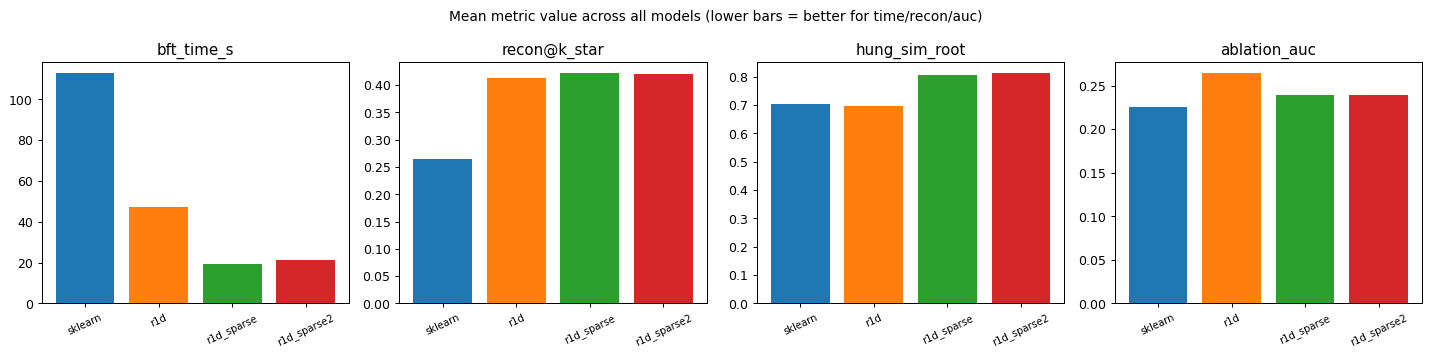

In [ ]:
# Radar-style bar chart comparing variants across metrics
models_with_ablation = df_summary[df_summary['ablation_auc'].notna()]['model'].unique()

metrics = ['bft_time_s', 'recon@k_star', 'hung_sim_root']
if not df_summary['ablation_auc'].isna().all():
    metrics.append('ablation_auc')

n_m = len(metrics)
fig, axes = plt.subplots(1, n_m, figsize=(4 * n_m, 4))

for ax, metric in zip(axes, metrics):
    vals = df_summary.groupby('variant')[metric].mean()
    bars = ax.bar(range(len(NMF_VARIANTS)),
                  [vals.get(v, float('nan')) for v in NMF_VARIANTS],
                  color=[NMF_COLORS[v] for v in NMF_VARIANTS])
    ax.set_xticks(range(len(NMF_VARIANTS)))
    ax.set_xticklabels(NMF_VARIANTS, rotation=25, fontsize=8)
    ax.set_title(metric)

fig.suptitle('Mean metric value across all models (lower bars = better for time/recon/auc)', fontsize=11)
plt.tight_layout()
plt.show()